In [ ]:
from zipfile import ZipFile
import os

In [34]:
zip_file_path = r"\\?\D:\project\Fashion Recommendations using Image Features\de18b-women-fashion.zip"
extraction_directory = r"\\?\D:\project\Fashion Recommendations using Image Features\de18b-women-fashion"

In [36]:
if not os.path.exists(extraction_directory):
    os.makedirs(extraction_directory)

In [38]:
with ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_directory)

In [40]:
extracted_files = os.listdir(extraction_directory)
print(extracted_files[:10])

['women fashion', '__MACOSX']


In [45]:
extraction_directory_updated = os.path.join(extraction_directory, 'women fashion')

In [47]:
extracted_files_updated = os.listdir(extraction_directory_updated)

In [49]:
extracted_files_updated[:10], len(extracted_files_updated)

(['.DS_Store',
  'anarkali suit with a long, olive green kurta adorned with intricate embroidery around the neckline and cuffs, paired with matching fitted trousers.jpg',
  'Anarkali suit with a modern twist.jpg',
  'Anarkali suit with fitted bodice with a high neckline.jpg',
  'anarkali suit with intricate silver embellishments on the neckline, sleeves.jpg',
  'anarkali suit with lavender in color with intricate white patterns throughout the fabric.jpg',
  'anarkali suit. It consists of a turquoise skirt with detailed golden embroidery, a multicolored blouse with floral patterns, and an orange dupatta with lace borders.jpg',
  'ark green, knee-length dress with short sleeves and a white, patterned neckline.jpg',
  'beige top adorned with black dots and a green skirt.jpg',
  'black and white gingham checkered A-line dress with a flared skirt.jpg'],
 97)

In [51]:
from PIL import Image
import matplotlib.pyplot as plt

In [53]:
def display_image(file_path):
    image = Image.open(file_path)
    plt.imshow(image)
    plt.axis('off')
    plt.show()

In [57]:
valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".gif")

In [59]:
image_files = [f for f in extracted_files_updated if f.lower().endswith(valid_extensions)]

In [61]:
print("Total images found:", len(image_files))
print("First 5 images:", image_files[:5])

Total images found: 89
First 5 images: ['anarkali suit with a long, olive green kurta adorned with intricate embroidery around the neckline and cuffs, paired with matching fitted trousers.jpg', 'Anarkali suit with a modern twist.jpg', 'Anarkali suit with fitted bodice with a high neckline.jpg', 'anarkali suit with intricate silver embellishments on the neckline, sleeves.jpg', 'anarkali suit with lavender in color with intricate white patterns throughout the fabric.jpg']


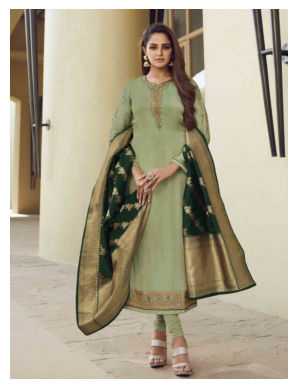

In [63]:
first_image_path = os.path.join(extraction_directory_updated, image_files[0])
display_image(first_image_path)

In [65]:
import glob

In [67]:
image_directory = r"D:\project\Fashion Recommendations using Image Features\de18b-women-fashion\women fashion"

In [69]:
image_paths_list = [file for file in glob.glob(os.path.join(image_directory, '*.*')) if file.endswith(('.jpg', '.png', '.jpeg', 'webp'))]

In [71]:
print(image_paths_list)

['D:\\project\\Fashion Recommendations using Image Features\\de18b-women-fashion\\women fashion\\anarkali suit with a long, olive green kurta adorned with intricate embroidery around the neckline and cuffs, paired with matching fitted trousers.jpg', 'D:\\project\\Fashion Recommendations using Image Features\\de18b-women-fashion\\women fashion\\Anarkali suit with a modern twist.jpg', 'D:\\project\\Fashion Recommendations using Image Features\\de18b-women-fashion\\women fashion\\Anarkali suit with fitted bodice with a high neckline.jpg', 'D:\\project\\Fashion Recommendations using Image Features\\de18b-women-fashion\\women fashion\\anarkali suit with intricate silver embellishments on the neckline, sleeves.jpg', 'D:\\project\\Fashion Recommendations using Image Features\\de18b-women-fashion\\women fashion\\anarkali suit with lavender in color with intricate white patterns throughout the fabric.jpg', 'D:\\project\\Fashion Recommendations using Image Features\\de18b-women-fashion\\women fa

In [73]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model
import numpy as np

In [75]:
base_model = VGG16(weights='imagenet', include_top=False)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [77]:
model = Model(inputs=base_model.input, outputs=base_model.output)

In [79]:
def preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array_expanded = np.expand_dims(img_array, axis=0)
    return preprocess_input(img_array_expanded)

In [81]:
def extract_features(model, preprocessed_img):
    features = model.predict(preprocessed_img)
    flattened_features = features.flatten()
    normalized_features = flattened_features / np.linalg.norm(flattened_features)
    return normalized_features

In [83]:
all_features = []
all_image_names = []

In [85]:
for img_path in image_paths_list:
    preprocessed_img = preprocess_image(img_path)
    features = extract_features(model, preprocessed_img)
    all_features.append(features)
    all_image_names.append(os.path.basename(img_path))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 668ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [87]:
from scipy.spatial.distance import cosine

In [89]:
def recommend_fashion_items_cnn(input_image_path, all_features, all_image_names, model, top_n=5):
    # pre-process the input image and extract features
    preprocessed_img = preprocess_image(input_image_path)
    input_features = extract_features(model, preprocessed_img)

    # calculate similarities and find the top N similar images
    similarities = [1 - cosine(input_features, other_feature) for other_feature in all_features]
    similar_indices = np.argsort(similarities)[-top_n:]

    # filter out the input image index from similar_indices
    similar_indices = [idx for idx in similar_indices if idx != all_image_names.index(input_image_path)]

    # display the input image
    plt.figure(figsize=(15, 10))
    plt.subplot(1, top_n + 1, 1)
    plt.imshow(Image.open(input_image_path))
    plt.title("Input Image")
    plt.axis('off')

    # display similar images
    for i, idx in enumerate(similar_indices[:top_n], start=1):
        image_path = os.path.join('/content/women_fashion/women fashion', all_image_names[idx])
        plt.subplot(1, top_n + 1, i + 1)
        plt.imshow(Image.open(image_path))
        plt.title(f"Recommendation {i}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step


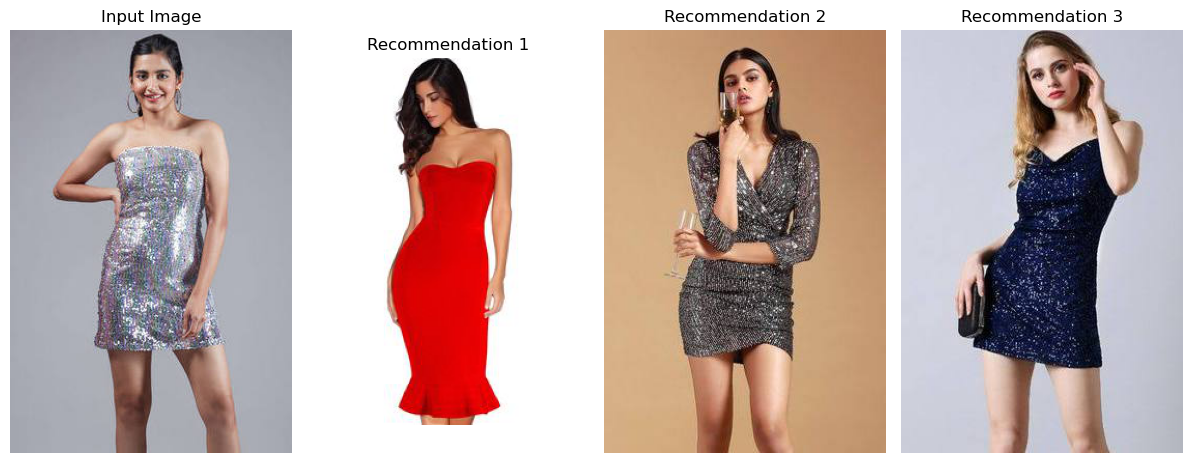

In [115]:
input_image_path = r"D:\project\Fashion Recommendations using Image Features\de18b-women-fashion\women fashion\strapless, sequined dress that sparkles with multiple colors.jpg"
recommend_fashion_items_cnn(input_image_path, all_features, image_paths_list, model, top_n=4)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step


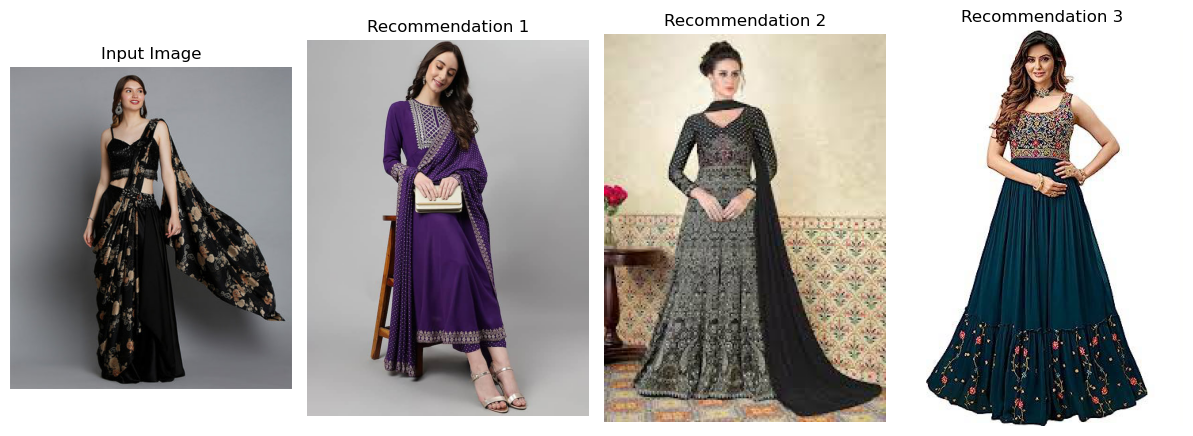

In [119]:
input_image_path = r"D:\project\Fashion Recommendations using Image Features\de18b-women-fashion\women fashion\black floral saree.jpg"
recommend_fashion_items_cnn(input_image_path, all_features, image_paths_list, model, top_n=4)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step


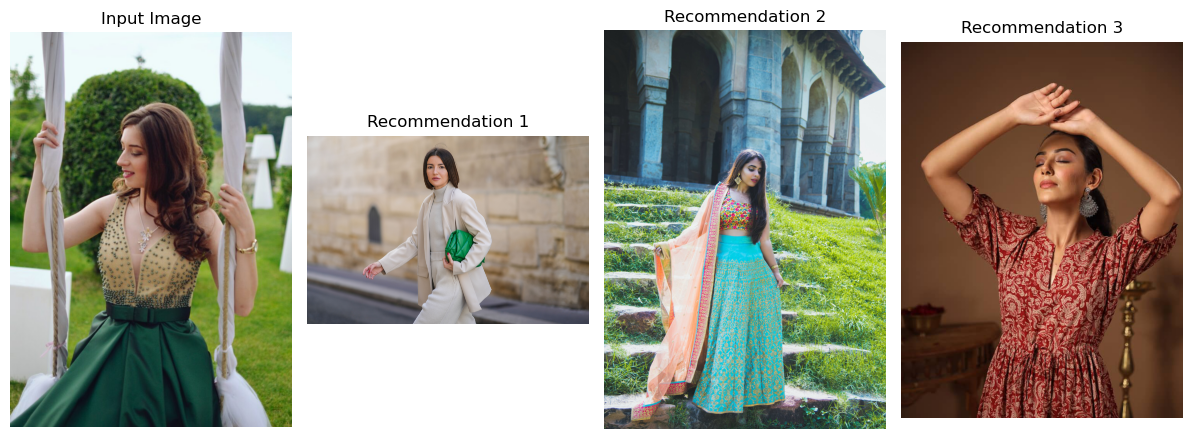

In [126]:
input_image_path = r"D:\project\Fashion Recommendations using Image Features\de18b-women-fashion\women fashion\beige top adorned with black dots and a green skirt.jpg"
recommend_fashion_items_cnn(input_image_path, all_features, image_paths_list, model, top_n=4)